In [1]:
from graph import graph
from IPython.display import Image

display(Image(graph.get_graph().draw_mermaid_png()))

ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [ ]:
# persistent_topic = "Ai in cybersecurity"

In [2]:
# Set the topic
from state import get_current_state

# Only ask for a topic if not already defined
try:
    persistent_topic
except NameError:
    persistent_topic = input("Enter your topic: ")

print(f"✅ Current topic: {persistent_topic}")

✅ Current topic: AI in cybersecurity


In [3]:
# Initialize the state based on persistent topic
current_state = get_current_state(topic=persistent_topic)

-------------------------------------------------------------------------------------------
Generating WiserAgents...



Accordion(children=(HTML(value='\n        <b>Name:</b> ThreatDetect<br>\n        <b>Expertise:</b> Threat Dete…

agents/wiseragents_pyvis.html


WiserAgents generated:
-------------------------------------------------------------------------------------------
>> Awaiting human feedback on WiserAgent output...
>> Feedback received. Looping back.
-------------------------------------------------------------------------------------------
✅ Skipping WiserAgent generation.
-------------------------------------------------------------------------------------------
>> Awaiting human feedback on WiserAgent output...
>> No feedback entered or already handled. Proceeding.
-------------------------------------------------------------------------------------------
Checking if question requires a Taskgraph...
Question requires some Task Graph planning
-------------------------------------------------------------------------------------------
Generating Task Graph for the user query...
Graphviz visualization saved to TG/saved_TGs/visuals/TG_ThreatDetect.png


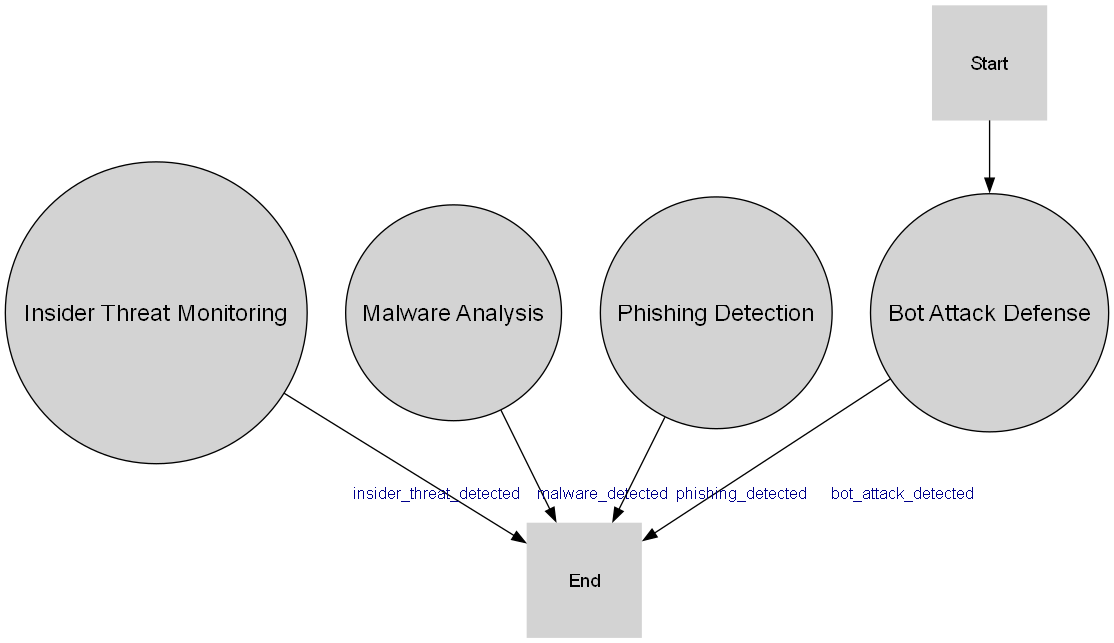

Task graph saved to TG/saved_TGs\TG_a15a7eaa.json
Graphviz visualization saved to TG/saved_TGs/visuals/TG_IntrusionPrevent.png


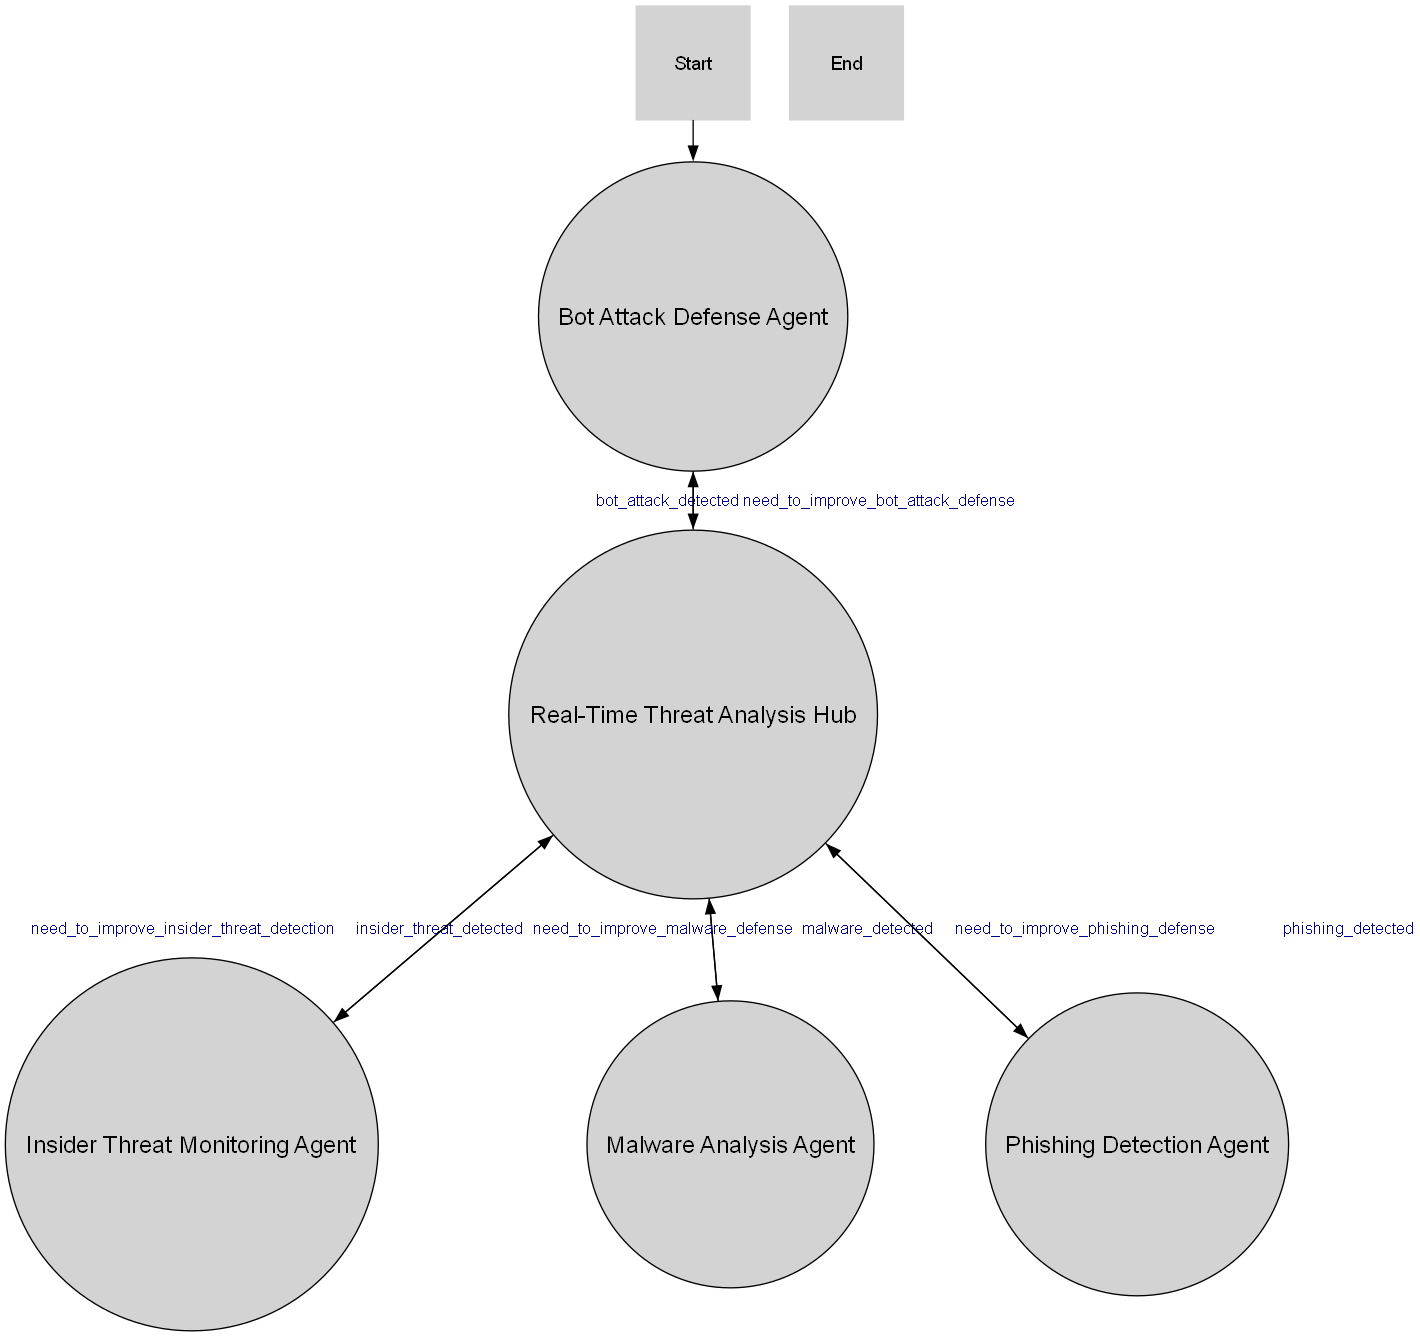

Task graph saved to TG/saved_TGs\TG_cf521ffa.json
Graphviz visualization saved to TG/saved_TGs/visuals/TG_NetSecMonitor.png


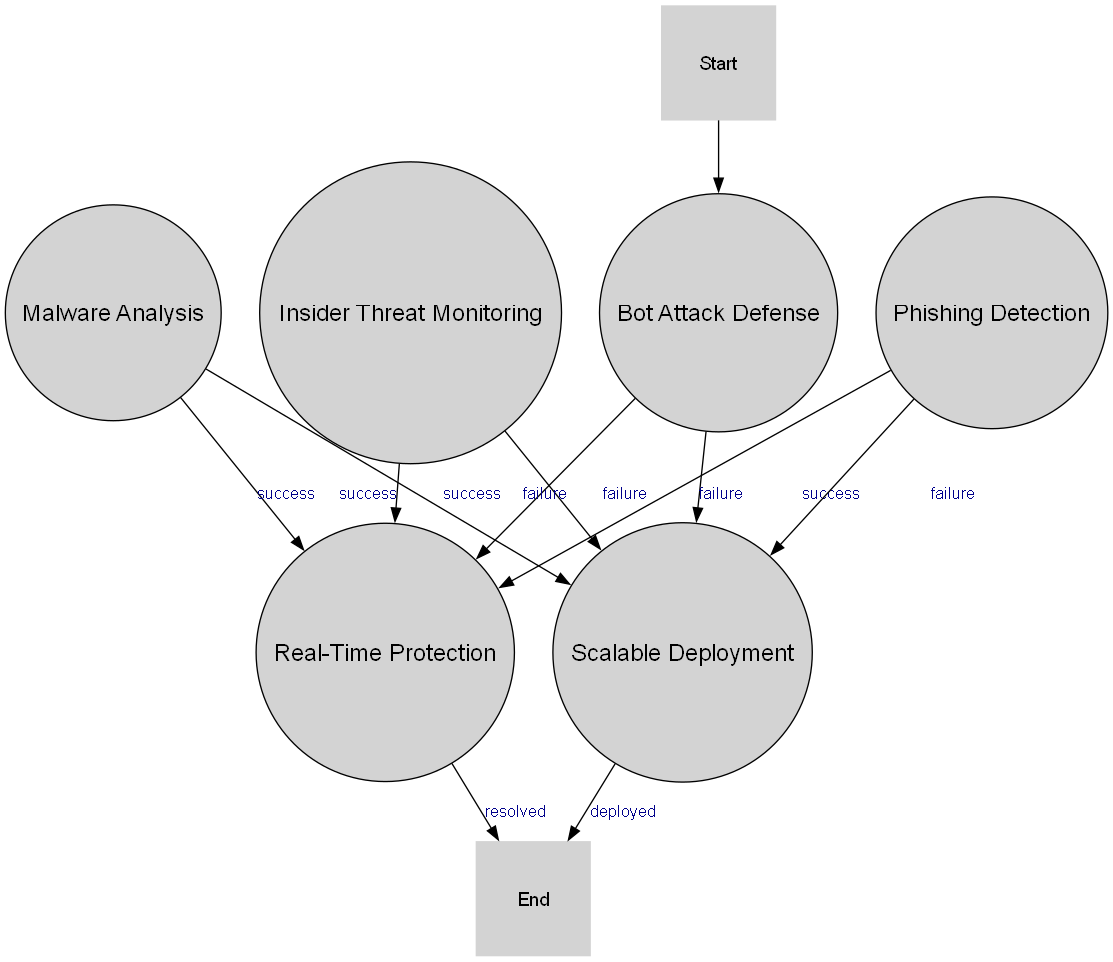

Task graph saved to TG/saved_TGs\TG_ce14727f.json
Graphviz visualization saved to TG/saved_TGs/visuals/TG_MalwareAnalyze.png


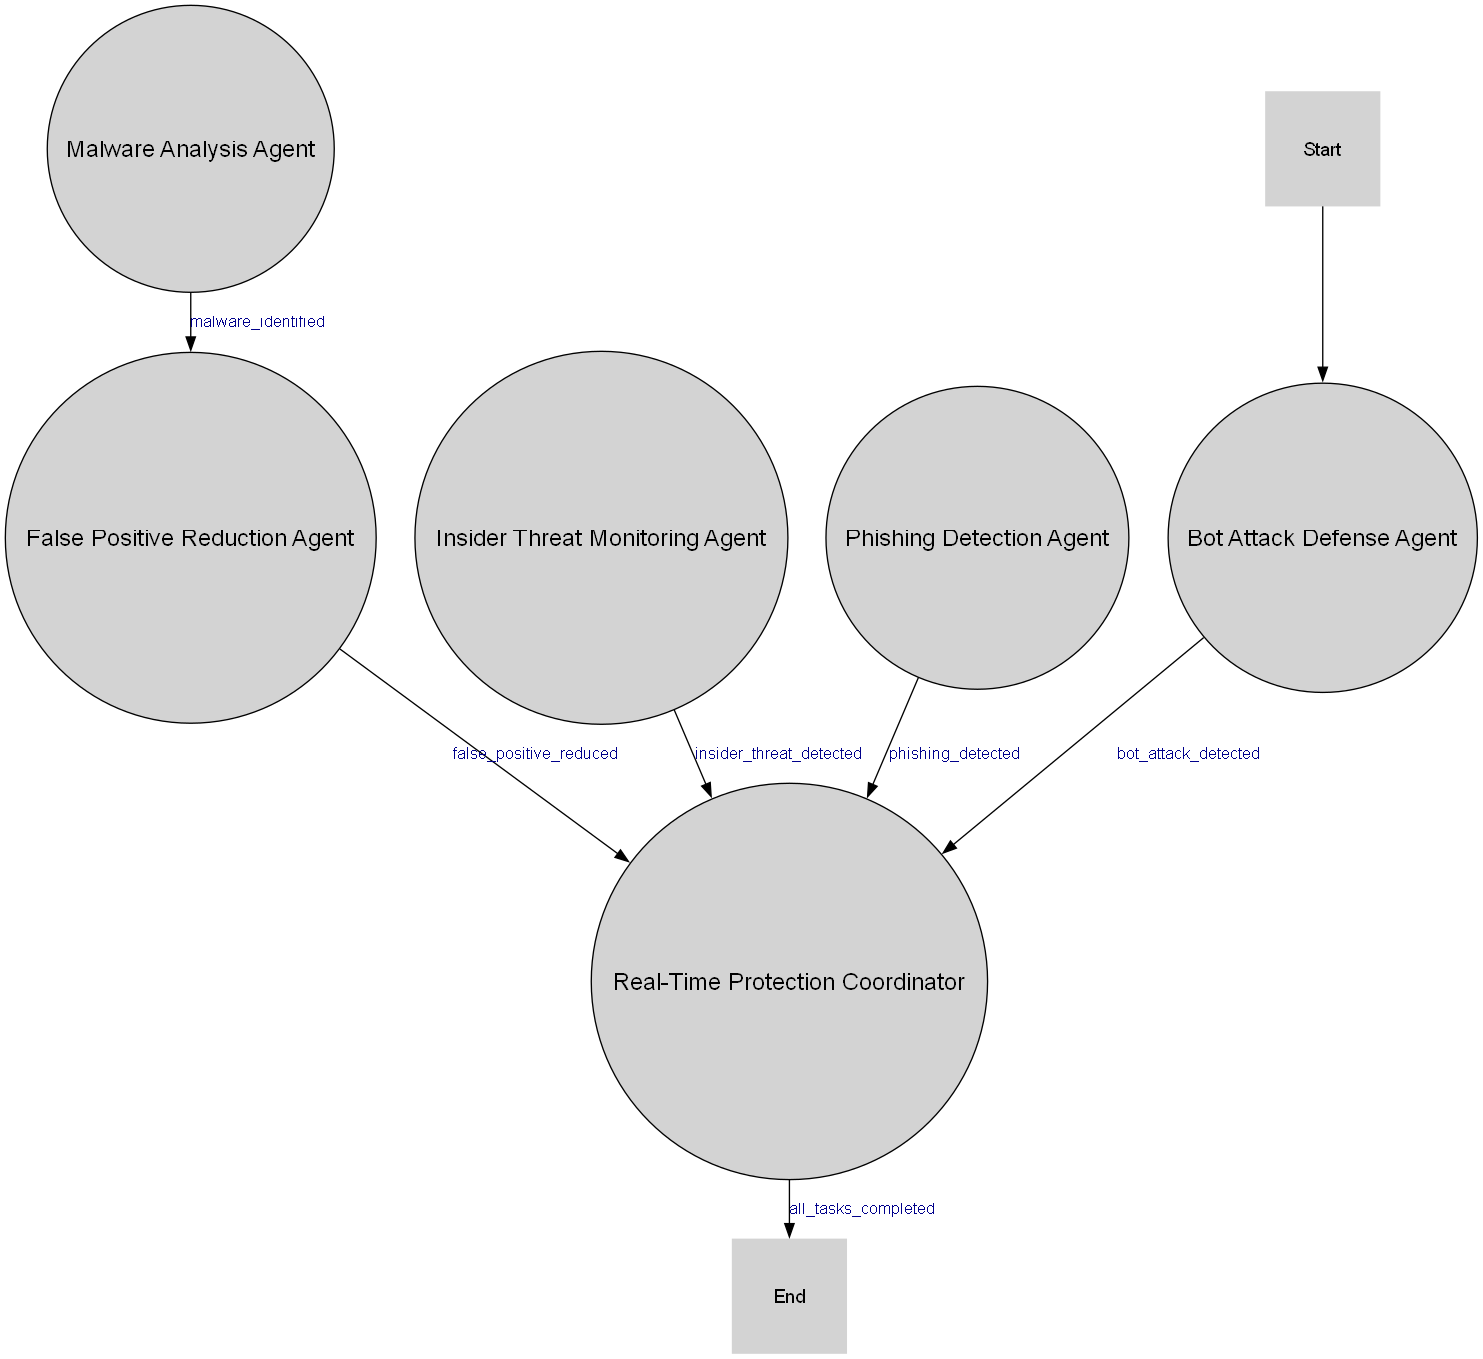

Task graph saved to TG/saved_TGs\TG_b6fd9b6e.json
Task Graphs generated.

-------------------------------------------------------------------------------------------
- Deep Monologue: Started
Interview questions saved to interview/saved_interviews\interview_97.json


Accordion(children=(VBox(children=(HTML(value="<b>👤 IntrusionPrevent :</b><br><span style='margin-left:20px;'>…

-------------------------------------------------------------------------------------------
web search requested by MalwareAnalyze in ThreatDetect interview
-------------------------------------------------------------------------------------------
WebSearch result :
 Link browsed: https://outshift.cisco.com/blog/exploring-the-potential-of-ai-agents-in-combatting-cyber-threats

Link browsed: https://www.lvt.com/blog/smarter-ai-for-safer-spaces-the-benefits-of-agentic-ai-and-agentic-automation-in-physical-security

Link browsed: https://www.rapidinnovation.io/post/ai-agents-for-cybersecurity-defense

-------------------------------------------------------------------------------------------
-----Deep Monologue: Ended-----
Interview answers updated in interview/saved_interviews\interview_97.json


Accordion(children=(VBox(children=(HTML(value="<b>👤 IntrusionPrevent :</b><br><span style='margin-left:20px;'>…

-------------------------------------------------------------------------------------------

>>> Chosen TG from agent: IntrusionPrevent


-------------------------------------------------------------------------------------------

Updated WS: 
ThreatDetect → WS = 49
IntrusionPrevent → WS = 51
NetSecMonitor → WS = 49
MalwareAnalyze → WS = 49
-----------------------------------------------------------------------------------------------
The answer: To design a multi-layered cybersecurity defense for your website using specialized AI agents, follow these steps:

1. Implement the Bot Attack Defense Agent to monitor and block suspicious activities in the network, ensuring real-time protection against bot attacks.
2. Deploy the Insider Threat Monitoring Agent to analyze employee behavior and access patterns, identifying potential insider threats early on.
3. Integrate the Malware Analysis Agent for real-time detection and removal of malware by analyzing system files and processes.
4. Set up the Phishing Detection Agent to identify and mitigate phishing threats through analysis of user interactions and network traffic.
5. Estab

In [5]:
# Run the graph
from graph import graph

thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(current_state, thread, stream_mode="values"):
    updated_state = event  # save the updated state
    print("-------------------------------------------------------------------------------------------")

In [6]:
# for event in graph.stream(updated_state, thread, stream_mode="values"):
#     print("-----------------------------------------------------------------------------------------------")


In [7]:
# Get state and look at next node
state = graph.get_state(thread)
print(state.next)
print(state)

()
StateSnapshot(values={'messages': [], 'topic': 'Ai in cybersecurity', 'last_topic': 'Ai in cybersecurity', 'query': 'How can I design a multi-layered cybersecurity defense for my website using a team of specialized AI agents, each responsible for different types of threats such as phishing, malware, bot attacks, and insider threats, while ensuring low false positives and scalable real-time protection?', 'human_wiseragent_feedback': '', 'feedback_handled': True, 'WS': 50, 'wiseragents': [WiserAgent(name='ThreatHunter', domain_expertise='Threat Detection and Analysis', description='ThreatHunter specializes in identifying and analyzing potential cyber threats using advanced AI techniques.', WS=51, preferred_llm='qwen2.5:latest'), WiserAgent(name='NetGuardian', domain_expertise='Network Security Monitoring', description='NetGuardian monitors network traffic to detect anomalies, ensuring the security of data transmission and communication channels.', WS=49, preferred_llm='qwen2.5:latest'

In [8]:
# Continue executing the graph
for event in graph.stream(None, thread, stream_mode="updates"):
    node_name = next(iter(event.keys()))
    print("-- Executed node:", node_name)

# Get the final state of the graph
final_state = graph.get_state(thread)
print("\nFinal State:")
print(final_state)


Final State:
StateSnapshot(values={'messages': [], 'topic': 'Ai in cybersecurity', 'last_topic': 'Ai in cybersecurity', 'query': 'How can I design a multi-layered cybersecurity defense for my website using a team of specialized AI agents, each responsible for different types of threats such as phishing, malware, bot attacks, and insider threats, while ensuring low false positives and scalable real-time protection?', 'human_wiseragent_feedback': '', 'feedback_handled': True, 'WS': 50, 'wiseragents': [WiserAgent(name='ThreatHunter', domain_expertise='Threat Detection and Analysis', description='ThreatHunter specializes in identifying and analyzing potential cyber threats using advanced AI techniques.', WS=51, preferred_llm='qwen2.5:latest'), WiserAgent(name='NetGuardian', domain_expertise='Network Security Monitoring', description='NetGuardian monitors network traffic to detect anomalies, ensuring the security of data transmission and communication channels.', WS=49, preferred_llm='qwen

In [9]:
# final chosen TG
final_tg = final_state.values.get('tg_chosen')
if final_tg:
    print("\nChosen TG:")
    print(final_tg.to_json())
else:
    print("\nNo TG chosen.")


Chosen TG:
{'owner_agent': 'ThreatHunter', 'tasks': {'Bot Attack Prevention Agent': 'Detects and mitigates bot attacks by analyzing network traffic patterns.', 'Insider Threat Monitoring Agent': 'Identifies potential insider threats through behavioral analysis of internal users.', 'Malware Analysis Agent': 'Analyzes suspicious files and URLs for malware threats.', 'Phishing Detection Agent': 'Monitors website traffic and user interactions to detect phishing attempts.', 'Real-Time Alerting System': 'Notifies security team about detected threats in real-time.'}, 'orders': [{'condition': 'phishing_detected', 'from': 'Phishing Detection Agent', 'to': 'Real-Time Alerting System'}, {'condition': 'malware_detected', 'from': 'Malware Analysis Agent', 'to': 'Real-Time Alerting System'}, {'condition': 'bot_attack_detected', 'from': 'Bot Attack Prevention Agent', 'to': 'Real-Time Alerting System'}, {'condition': 'insider_threat_detected', 'from': 'Insider Threat Monitoring Agent', 'to': 'Real-Ti